In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = [10, 5]

plt.style.use('ggplot')

from matplotlib import rc
#rc('ps', useafm=True)
rc('pdf', use14corefonts=True)
rc('text', usetex=True)
rc('font', family='sans-serif')
rc('font', **{'sans-serif': ['Computer Modern']})
rc('font', size=14)
rc('axes', grid=False)

In [2]:
import re

RUN_DIR_RE = re.compile(r"M(?P<M>\d+)_nbits(?P<nbits>\d+)")
PS_RE = re.compile(r"ps(?P<ps>\d+)")


def parse_dir_name(dirname: str) -> dict:

    parts = dirname.split("__")
    if len(parts) < 4:
        raise ValueError(f"Unexpected run dir name format: {dirname}")

    train_ds = parts[0]          # e.g. 'msmarco-passage-train'
    model_name = parts[1]        # e.g. 'tct_colbert'
    pq_impl = parts[2]           # e.g. 'faiss2opq'
    M_nbits = parts[3]           # e.g. 'M128_nbits10'
    ps_part = parts[4] if len(parts) > 4 else ""

    m_match = RUN_DIR_RE.search(M_nbits)
    if not m_match:
        raise ValueError(f"Cannot parse M/nbits from '{M_nbits}' in {dirname}")

    M = int(m_match.group("M"))
    nbits = int(m_match.group("nbits"))

    ps_match = PS_RE.search(ps_part)
    ps = int(ps_match.group("ps")) if ps_match else None

    return {
        "train_ds": train_ds,
        "model": model_name,
        "pq_impl": pq_impl,
        "M": M,
        "nbits": nbits,
        "pq_sample_size": ps,
    }


In [3]:
import pandas as pd
from pathlib import Path

def load_single_metrics_csv(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, index_col=0)
    if "name" not in df.columns:
        raise ValueError(f"'name' column not found in {csv_path}")
    return df

In [4]:
import numpy as np

def collect_all_results(root: Path, split: str = '2019') -> pd.DataFrame:
    rows = []

    for run_dir in root.iterdir():
        if not run_dir.is_dir():
            continue

        metrics_path = run_dir / "runs" / ("test-" + split) / "metrics.csv"
        if not metrics_path.is_file():
            continue

        try:
            meta = parse_dir_name(run_dir.name)
        except ValueError as e:
            # skip dirs that do not follow naming convention
            print(f"[WARN] Skipping {run_dir}: {e}")
            continue

        try:
            df = load_single_metrics_csv(metrics_path)
        except Exception as e:
            print(f"[WARN] Failed to read {metrics_path}: {e}")
            continue
        
        for _, row in df.iterrows():
            rec = dict(meta)  # copy metadata
            rec["variant"] = row["name"]  # e.g. 'baseline', 'JPQ pq'

            # pull the metrics we care about (if present)
            for col in ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10", "mrt"]:
                if col in df.columns:
                    rec[col] = row[col]
                else:
                    rec[col] = np.nan
            rec["index_name"] = run_dir.name
            rows.append(rec)

    if not rows:
        raise RuntimeError(f"No results found under {root}")

    return pd.DataFrame(rows)

In [5]:
metrics = ["R(rel=2)@100", "nDCG@10", "R@100", "RR@10"]
df = collect_all_results(Path('Mbitsscan/'), split='2019')

In [6]:
df

,train_ds,model,pq_impl,M,nbits,pq_sample_size,variant,R(rel=2)@100,nDCG@10,R@100,RR@10,mrt,index_name
0,msmarco-passage-train,tct_colbert,faiss2opq,24,10,159744,baseline,0.607978,0.718035,0.514889,0.988372,94576.358152,msmarco-passage-train__tct_colbert__faiss2opq_...
1,msmarco-passage-train,tct_colbert,faiss2opq,24,10,159744,JPQ pq,0.368164,0.468653,0.289184,0.782946,78714.263563,msmarco-passage-train__tct_colbert__faiss2opq_...
2,msmarco-passage-train,tct_colbert,faiss2opq,128,4,159744,baseline,0.607978,0.718035,0.514889,0.988372,59770.394192,msmarco-passage-train__tct_colbert__faiss2opq_...
3,msmarco-passage-train,tct_colbert,faiss2opq,128,4,159744,JPQ pq,0.528652,0.601351,0.435412,0.913437,73269.383898,msmarco-passage-train__tct_colbert__faiss2opq_...
4,msmarco-passage-train,tct_colbert,faiss2opq,256,6,159744,baseline,0.607978,0.718035,0.514889,0.988372,24449.326102,msmarco-passage-train__tct_colbert__faiss2opq_...
5,msmarco-passage-train,tct_colbert,faiss2opq,256,6,159744,JPQ pq,0.542673,0.641049,0.445325,0.909884,161379.056748,msmarco-passage-train__tct_colbert__faiss2opq_...
6,msmarco-passage-train,tct_colbert,faiss2opq,48,10,159744,baseline,0.607978,0.718035,0.514889,0.988372,19330.579262,msmarco-passage-train__tct_colbert__faiss2opq_...
7,msmarco-passage-train,tct_colbert,faiss2opq,48,10,159744,JPQ pq,0.531147,0.617659,0.413023,0.884496,27010.731056,msmarco-passage-train__tct_colbert__faiss2opq_...
8,msmarco-passage-train,tct_colbert,faiss2opq,256,8,159744,baseline,0.607978,0.718035,0.514889,0.988372,108885.551353,msmarco-passage-train__tct_colbert__faiss2opq_...
9,msmarco-passage-train,tct_colbert,faiss2opq,256,8,159744,JPQ pq,0.546371,0.636285,0.438963,0.951550,42334.082436,msmarco-passage-train__tct_colbert__faiss2opq_...


In [7]:
def load_index_sizes(root: str | Path, inv_name: str = "file_inventory.csv") -> pd.DataFrame:
    root = Path(root)
    rows = []
    for inv in root.rglob(inv_name):
        try:
            t = pd.read_csv(inv)
        except Exception:
            continue
        total = int(t["size_bytes"].sum())
        rows.append({
            "index_path": str(inv.parent),
            "index_name": inv.parent.name,
            "total_size_bytes": total,
        })
    return pd.DataFrame(rows)

In [8]:
sizes = load_index_sizes("Mbitsscan/")

In [9]:
sizes

,index_path,index_name,total_size_bytes
0,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,867864782
1,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,1572114044
2,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,2704014844
3,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,1292272286
4,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,2704604669
5,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,2706963966
6,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,1301709470
7,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,652564452
8,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,1289912988
9,Mbitsscan/msmarco-passage-train__tct_colbert__...,msmarco-passage-train__tct_colbert__faiss2opq_...,4970470654


In [10]:
merged = df.merge(sizes, on="index_name", how="inner")

In [11]:
merged

,train_ds,model,pq_impl,M,nbits,pq_sample_size,variant,R(rel=2)@100,nDCG@10,R@100,RR@10,mrt,index_name,index_path,total_size_bytes
0,msmarco-passage-train,tct_colbert,faiss2opq,24,10,159744,baseline,0.607978,0.718035,0.514889,0.988372,94576.358152,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,867864782
1,msmarco-passage-train,tct_colbert,faiss2opq,24,10,159744,JPQ pq,0.368164,0.468653,0.289184,0.782946,78714.263563,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,867864782
2,msmarco-passage-train,tct_colbert,faiss2opq,128,4,159744,baseline,0.607978,0.718035,0.514889,0.988372,59770.394192,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,1572114044
3,msmarco-passage-train,tct_colbert,faiss2opq,128,4,159744,JPQ pq,0.528652,0.601351,0.435412,0.913437,73269.383898,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,1572114044
4,msmarco-passage-train,tct_colbert,faiss2opq,256,6,159744,baseline,0.607978,0.718035,0.514889,0.988372,24449.326102,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,2704014844
5,msmarco-passage-train,tct_colbert,faiss2opq,256,6,159744,JPQ pq,0.542673,0.641049,0.445325,0.909884,161379.056748,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,2704014844
6,msmarco-passage-train,tct_colbert,faiss2opq,48,10,159744,baseline,0.607978,0.718035,0.514889,0.988372,19330.579262,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,1292272286
7,msmarco-passage-train,tct_colbert,faiss2opq,48,10,159744,JPQ pq,0.531147,0.617659,0.413023,0.884496,27010.731056,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,1292272286
8,msmarco-passage-train,tct_colbert,faiss2opq,256,8,159744,baseline,0.607978,0.718035,0.514889,0.988372,108885.551353,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,2704604669
9,msmarco-passage-train,tct_colbert,faiss2opq,256,8,159744,JPQ pq,0.546371,0.636285,0.438963,0.951550,42334.082436,msmarco-passage-train__tct_colbert__faiss2opq_...,Mbitsscan/msmarco-passage-train__tct_colbert__...,2704604669


In [12]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def pareto_frontier(df: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    """
    Frontier where x is to be minimized (size) and y maximized (effectiveness).
    Returns points on the frontier sorted by x ascending.
    """
    d = df[[x, y]].dropna().sort_values(x, ascending=True).copy()
    best = -np.inf
    keep = []
    for _, row in d.iterrows():
        if row[y] > best:
            best = row[y]
            keep.append(True)
        else:
            keep.append(False)
    return d.loc[keep].sort_values(x, ascending=True)

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_effectiveness_vs_size(
    df,
    metric: str,
    *,
    size_col: str = "total_size_bytes",
    label_cols: tuple[str, ...] = ("M", "nbits"),
    title: str | None = None,
    log_x: bool = True,
    connect_all: bool = True,
    annotate: bool = True,
):
    d = df.dropna(subset=[size_col, metric]).copy()
    d["size_gb"] = d[size_col] / (1024**3)

    # Sort by size for line plotting
    d = d.sort_values("size_gb")

    fig, ax = plt.subplots(figsize=(8, 6))

    # --- scatter ---
    ax.scatter(d["size_gb"], d[metric], zorder=3)

    # --- connect all points (optional) ---
    if connect_all:
        ax.plot(d["size_gb"], d[metric], alpha=0.3, linestyle="--", zorder=1)

    # --- Pareto frontier (min size, max effectiveness) ---
    best = -np.inf
    front_idx = []
    for i, row in d.iterrows():
        if row[metric] > best:
            best = row[metric]
            front_idx.append(i)

    front = d.loc[front_idx]

    ax.plot(
        front["size_gb"],
        front[metric],
        color="red",
        linewidth=2.5,
        marker="o",
        zorder=4,
#        label="Pareto frontier",
    )

    # --- annotations ---
    if annotate:
        for _, r in d.iterrows():
            label = ",".join(str(r[c]) for c in label_cols if c in r)
            ax.annotate(
                label,
                (r["size_gb"], r[metric]),
                textcoords="offset points",
                xytext=(6, 4),
                fontsize=8,
                alpha=0.8,
            )

    if log_x:
        ax.set_xscale("log")

    ax.set_xlabel("Total index size (GB)")
    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} vs total index size")
    ax.grid(True, which="both", linestyle=":", linewidth=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2454900/157753940.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


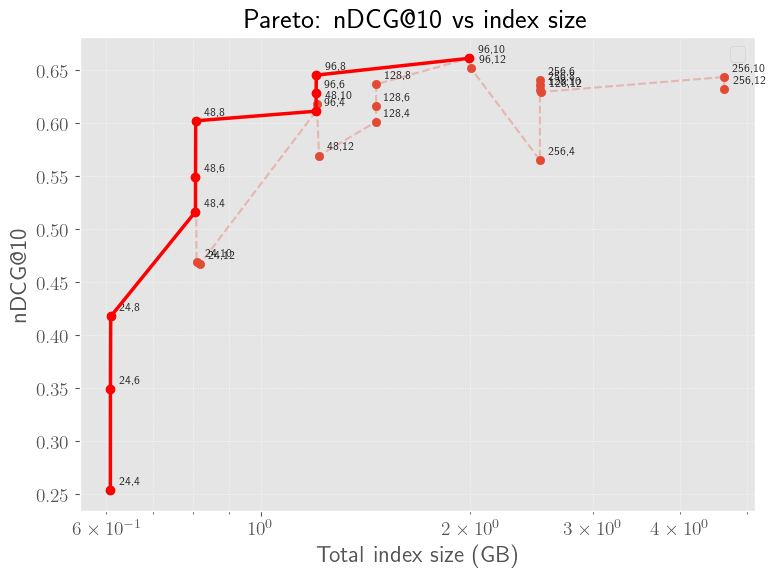

In [14]:
plot_effectiveness_vs_size(
    merged[merged.variant != 'baseline'],
    metric="nDCG@10",
    label_cols=("M", "nbits"),  # labels like "4,8"
    title="Pareto: nDCG@10 vs index size",
    log_x=True,
    connect_all=True,
    annotate=True,
)

/tmp/ipykernel_2454900/157753940.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


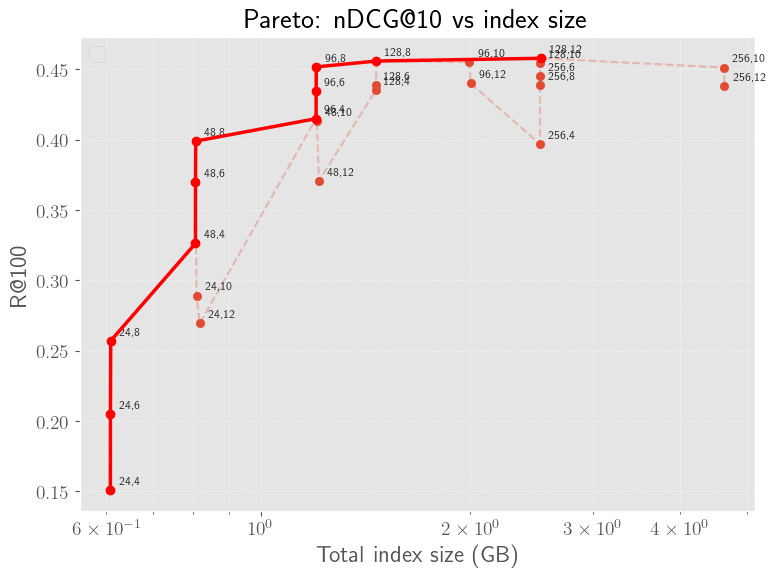

In [15]:
plot_effectiveness_vs_size(
    merged[merged.variant != 'baseline'],
    metric="R@100",
    label_cols=("M", "nbits"),  # labels like "4,8"
    title="Pareto: nDCG@10 vs index size",
    log_x=True,
    connect_all=True,
    annotate=True,
)

/tmp/ipykernel_2454900/157753940.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


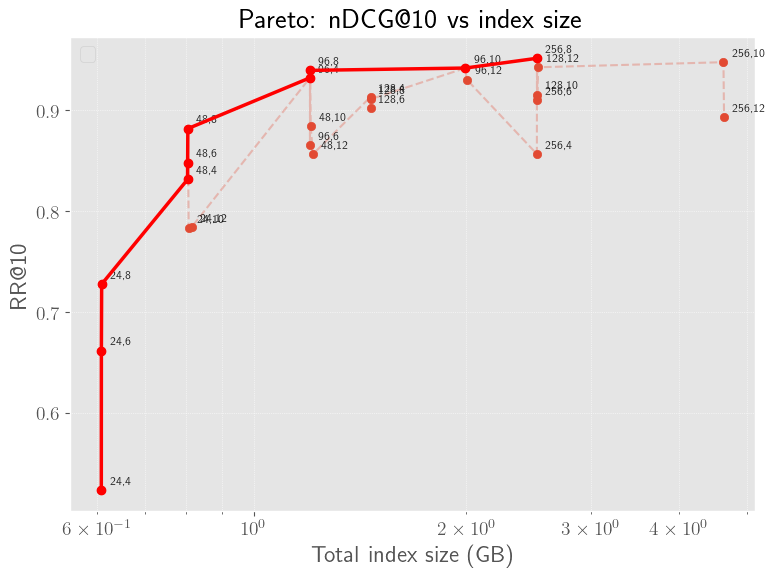

In [16]:
plot_effectiveness_vs_size(
    merged[merged.variant != 'baseline'],
    metric="RR@10",
    label_cols=("M", "nbits"),  # labels like "4,8"
    title="Pareto: nDCG@10 vs index size",
    log_x=True,
    connect_all=True,
    annotate=True,
)